# 4.1 Evaluation metrics: session overview

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
df = pd.read_csv('Churn_pred_data.csv')

df.columns = df.columns.str.lower().str.replace(' ', '_')

categorical_columns = list(df.dtypes[df.dtypes == 'object'].index)

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')
df.totalcharges = df.totalcharges.fillna(0)

df.churn = (df.churn == 'yes').astype(int)

In [2]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

del df_train['churn']
del df_val['churn']
del df_test['churn']

In [3]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']

categorical = [
    'gender',
    'seniorcitizen',
    'partner',
    'dependents',
    'phoneservice',
    'multiplelines',
    'internetservice',
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies',
    'contract',
    'paperlessbilling',
    'paymentmethod',
]

In [8]:
dv = DictVectorizer(sparse=False)

train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

model = LogisticRegression(max_iter = 2500)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2500
,multi_class,'deprecated'


In [10]:
val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

y_pred = model.predict_proba(X_val)[:, 1]
churn_decision = (y_pred >= 0.5)
print((y_val == churn_decision).mean())

0.8034066713981547


# 4.2 Accuracy and dummy model

In [12]:
full_data = len(y_val)

In [18]:
correct_pred = (y_val == churn_decision).sum()

In [19]:
(y_val == churn_decision).mean()

np.float64(0.8034066713981547)

In [20]:
correct_pred/full_data

np.float64(0.8034066713981547)

In [23]:
thresholds = np.linspace(0,1,21)
scores = []
for i in thresholds:
    churn_decision = (y_pred >= i)
    score = (y_val == churn_decision).mean()
    print("%.2f, %3f"%(i,score))
    scores.append(score)

0.00, 0.273953
0.05, 0.513130
0.10, 0.607523
0.15, 0.661462
0.20, 0.702626
0.25, 0.733854
0.30, 0.757984
0.35, 0.765082
0.40, 0.782115
0.45, 0.791341
0.50, 0.803407
0.55, 0.801278
0.60, 0.795600
0.65, 0.788502
0.70, 0.765791
0.75, 0.742370
0.80, 0.728886
0.85, 0.726047
0.90, 0.726047
0.95, 0.726047
1.00, 0.726047


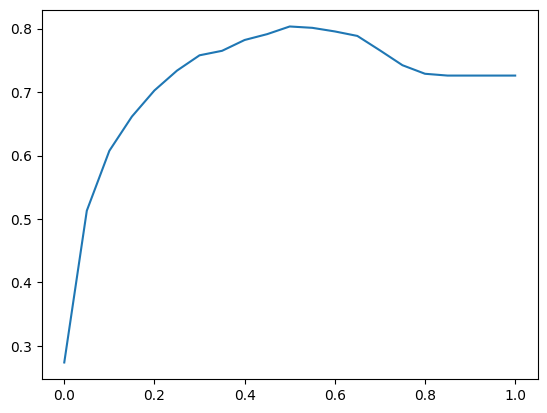

In [28]:
plt.plot(thresholds,scores)

In [29]:
from sklearn.metrics import accuracy_score

In [31]:
accuracy_score(y_val,y_pred >= 0.5)

0.8034066713981547